## 1. Problem Understanding

### CIFAR-10 — CNN-Based Image Classification

The **CIFAR-10** project aims to classify images into their corresponding categories using a **Convolutional Neural Network (CNN)**.

The CIFAR-10 dataset consists of small **RGB images of size 32 × 32 pixels**, belonging to **10 different classes**:

- **airplane**
- **automobile**
- **bird**
- **cat**
- **deer**
- **dog**
- **frog**
- **horse**
- **ship**
- **truck**

Unlike tabular datasets, images contain important **spatial information**, where nearby pixels are related to one another. A CNN is therefore used to learn spatial patterns such as edges, textures, shapes, and higher-level visual features from the images.

#### Project Objective

Build and evaluate a **CNN-based multiclass classification model** capable of predicting the correct class of a given CIFAR-10 image.

#### Problem Type

**Supervised Learning → Multiclass Image Classification**

#### Input

Each image has:

- **Height:** 32 pixels
- **Width:** 32 pixels
- **Channels:** 3 (RGB)

Therefore, each image contains:

**32 × 32 × 3 = 3072 pixel values**

For PyTorch, the image is represented in **Channel × Height × Width (C × H × W)** format:

**3 × 32 × 32**

#### Output

The CNN produces **10 output scores**, one for each CIFAR-10 class.

The class corresponding to the highest output score is taken as the predicted class.

#### Model Development Strategy

The project will follow a structured deep-learning workflow:

**Data Loading → Data Understanding → Exploratory Data Analysis → Data Preprocessing → CNN Baseline → Stratified Holdout Validation → Hyperparameter Optimization using Optuna → Final Retraining → Final Evaluation → Error Analysis → Model Saving → Random-Sample Model Inference**

The official **test dataset will remain untouched during model development, validation, and hyperparameter optimization** and will be used only for the final evaluation of the selected model.

## 2. Library & Dataset Loading

### 2.1 Import Required Libraries

We begin by importing the libraries required for data loading, visualization, preprocessing, reproducibility, CNN development, model evaluation, cross-validation, and hyperparameter optimization.

- **NumPy** → numerical operations
- **Matplotlib & Seaborn** → visualization and EDA
- **PyTorch** → CNN architecture and deep-learning operations
- **Torchvision** → CIFAR-10 dataset and image transformations
- **Scikit-Learn** → model evaluation and cross-validation utilities
- **Skorch** → integrating the PyTorch CNN with the Scikit-Learn API
- **Optuna** → hyperparameter optimization

In [1]:
import os
import random
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

from skorch import NeuralNetClassifier
import optuna

# Ensure images directory exists for saving figures
os.makedirs("images", exist_ok=True)

# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Select computation device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)
print("Device:", device)

PyTorch version: 2.14.0+cu130
Torchvision version: 0.29.0+cu130
Device: cuda


In [2]:
print("Device:", device)

Device: cuda


### 2.2 Load the Dataset

The **CIFAR-10 dataset** is provided through `torchvision`. It contains separate training and test datasets.

In [3]:
# Training transformation
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

# Evaluation transformation
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

In [4]:
# Training dataset with data augmentation
trainset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

# Clean training dataset with deterministic evaluation transform (for validation)
trainset_eval = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=test_transform
)

# Test dataset with deterministic evaluation transform
testset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

## 3. Data Understanding

In [5]:
# Dataset structure

print("Number of training images:", len(trainset))
print("Image data shape:", trainset.data.shape)
print("Image dimensions:", trainset.data.shape[1:])
print("Number of target classes:", len(trainset.classes))

print("\nClasses:")
print(trainset.classes)

Number of training images: 50000
Image data shape: (50000, 32, 32, 3)
Image dimensions: (32, 32, 3)
Number of target classes: 10

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# Pixel data properties

print("Pixel data type:", trainset.data.dtype)
print("Minimum pixel value:", trainset.data.min())
print("Maximum pixel value:", trainset.data.max())
print("Mean pixel value:", trainset.data.mean())

Pixel data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Mean pixel value: 120.70756512369792


In [7]:
# Examine target labels

print("First 20 target labels:")
print(trainset.targets[:20])

print("\nUnique target labels:")
print(sorted(set(trainset.targets)))

First 20 target labels:
[6, 9, 9, 4, 1, 1, 2, 7, 8, 3, 4, 7, 7, 2, 9, 9, 9, 3, 2, 6]

Unique target labels:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [8]:
# Calculate class distribution

class_counts = np.bincount(trainset.targets)

for class_name, count in zip(trainset.classes, class_counts):
    print(f"{class_name:10s}: {count}")

airplane  : 5000
automobile: 5000
bird      : 5000
cat       : 5000
deer      : 5000
dog       : 5000
frog      : 5000
horse     : 5000
ship      : 5000
truck     : 5000


## 4. Exploratory Data Analysis (EDA)

### 4.1 Target Class Distribution

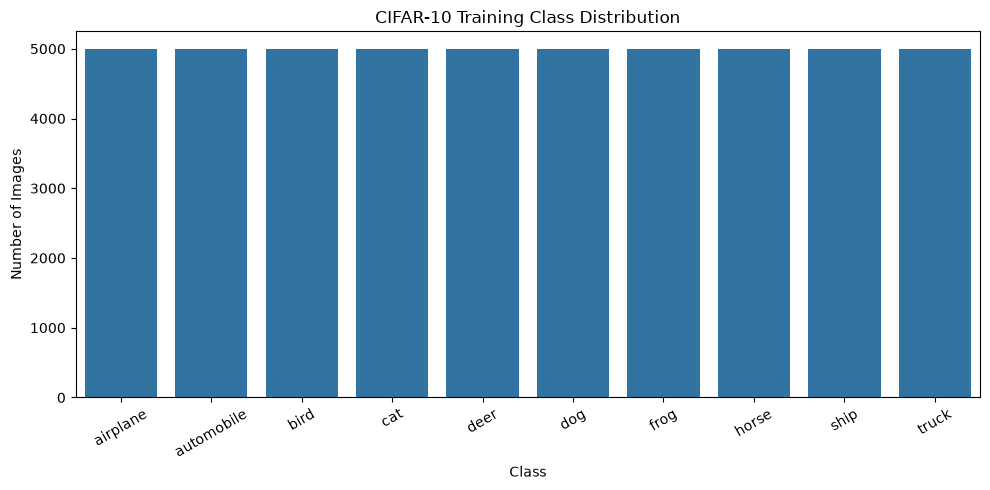

In [9]:
# Visualize class distribution

plt.figure(figsize=(10, 5))

sns.barplot(
    x=trainset.classes,
    y=class_counts
)

plt.title("CIFAR-10 Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)

plt.tight_layout()

plt.savefig(
    "images/cifar10_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.2 Sample Image Visualization

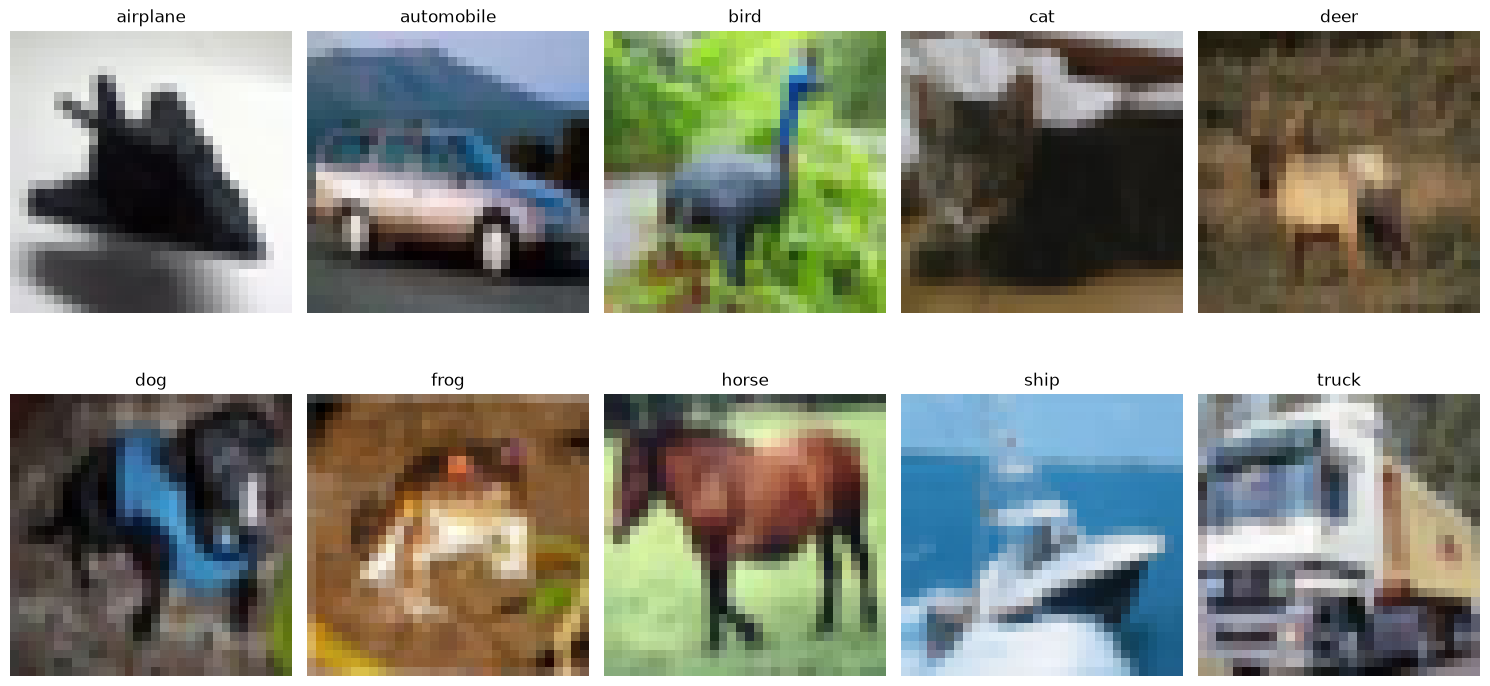

In [10]:
# Display sample images from each class

plt.figure(figsize=(15, 8))

for class_index, class_name in enumerate(trainset.classes):
    
    # Find the first image belonging to the current class
    image_index = trainset.targets.index(class_index)
    
    image = trainset.data[image_index]

    plt.subplot(2, 5, class_index + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "images/cifar10_sample_images.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### 4.3 Pixel Intensity Distribution

In [11]:
# Calculate pixel intensity statistics for each RGB channel

channel_names = ["Red", "Green", "Blue"]

for channel_index, channel_name in enumerate(channel_names):
    channel_data = trainset.data[:, :, :, channel_index]

    print(
        f"{channel_name}: "
        f"Mean = {channel_data.mean():.2f}, "
        f"Std = {channel_data.std():.2f}, "
        f"Min = {channel_data.min()}, "
        f"Max = {channel_data.max()}"
    )

Red: Mean = 125.31, Std = 62.99, Min = 0, Max = 255
Green: Mean = 122.95, Std = 62.09, Min = 0, Max = 255
Blue: Mean = 113.87, Std = 66.70, Min = 0, Max = 255


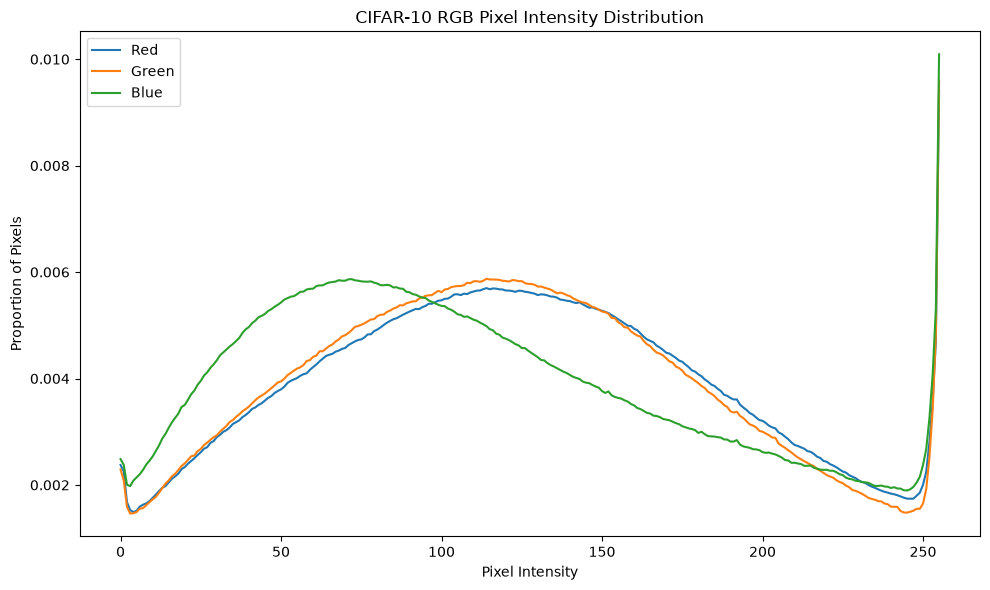

In [12]:
# Calculate exact pixel intensity frequencies for each RGB channel

channel_names = ["Red", "Green", "Blue"]

plt.figure(figsize=(10, 6))

for channel_index, channel_name in enumerate(channel_names):

    # Extract all pixels from the channel
    channel_data = trainset.data[:, :, :, channel_index]

    # Count occurrences of every intensity value from 0 to 255
    intensity_counts = np.bincount(
        channel_data.ravel(),
        minlength=256
    )

    # Convert counts into proportions
    intensity_distribution = intensity_counts / intensity_counts.sum()

    plt.plot(
        range(256),
        intensity_distribution,
        label=channel_name
    )

plt.title("CIFAR-10 RGB Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Proportion of Pixels")
plt.legend()

plt.tight_layout()

plt.savefig(
    "images/cifar10_pixel_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5. CNN Model 

In [13]:
from sklearn.pipeline import Pipeline


In [ ]:
class CNN(nn.Module):
    def __init__(self, fc_size=256, dropout_rate=0.3, activation=nn.ReLU):
        super().__init__()

        self.features = nn.Sequential(
            # Stage 1: Conv -> BatchNorm -> Activation -> MaxPool (32x32 -> 16x16)
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            activation(),
            nn.MaxPool2d(2),

            # Stage 2: Conv -> BatchNorm -> Activation -> MaxPool (16x16 -> 8x8)
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            activation(),
            nn.MaxPool2d(2),

            # Stage 3: Conv -> BatchNorm -> Activation -> MaxPool (8x8 -> 4x4)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            activation(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, fc_size),
            nn.BatchNorm1d(fc_size),
            activation(),
            nn.Dropout(dropout_rate),
            nn.Linear(fc_size, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Calculate trainable parameters directly from PyTorch model
_model_summary = CNN()
total_trainable_params = sum(p.numel() for p in _model_summary.parameters() if p.requires_grad)
print(f"Total Trainable Parameters: {total_trainable_params:,}")

Total Trainable Parameters: 621,322


In [15]:
net = NeuralNetClassifier(
    module=CNN,
    module__fc_size=256,
    module__dropout_rate=0.3,
    module__activation=nn.ReLU,

    criterion=nn.CrossEntropyLoss,
    optimizer=optim.Adam,
    optimizer__weight_decay=0.0001,

    lr=0.001,
    max_epochs=12,
    batch_size=64,

    device=device,

    train_split=None,
    warm_start=False,
    verbose=0
)

In [16]:
cnn_pipeline = Pipeline([("model", net)])

## 6. Baseline CNN Training & Visualization

In [17]:
cnn_pipeline.fit(trainset)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,module,<class '__main__.CNN'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.001
,max_epochs,12
,batch_size,64


In [18]:
model = cnn_pipeline.named_steps["model"]
history = model.history

print("Number of epochs:", len(history))
print("Epoch 1 Training Loss:", history[0]["train_loss"])
print("Final Training Loss:", history[-1]["train_loss"])
print(
    "Loss Reduction:",
    history[0]["train_loss"] - history[-1]["train_loss"]
)

Number of epochs: 12
Epoch 1 Training Loss: 1.2900604748535156
Final Training Loss: 0.5549502717590332
Loss Reduction: 0.7351102030944824


In [19]:
predictions = cnn_pipeline.predict(trainset_eval)
true_labels = np.array(trainset_eval.targets)

training_accuracy = np.mean(predictions == true_labels)

print(f"Training Accuracy: {training_accuracy:.4f}")
print(f"Training Accuracy: {training_accuracy * 100:.2f}%")

Training Accuracy: 0.8586
Training Accuracy: 85.86%


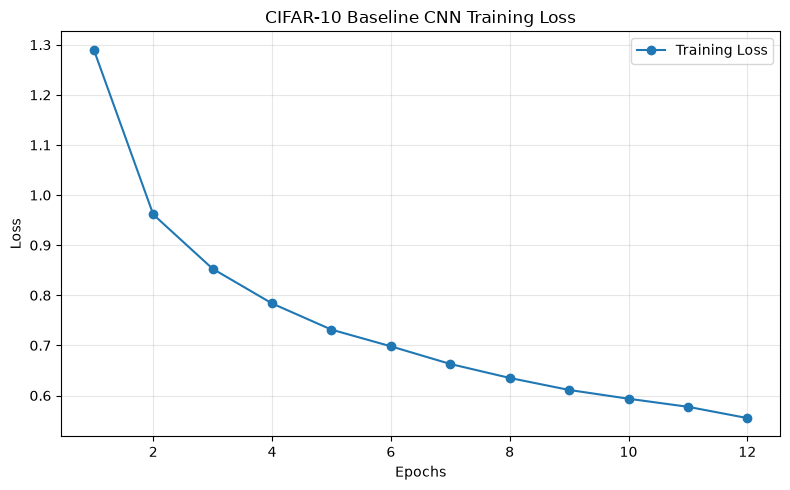

In [20]:
epochs = range(1, len(history) + 1)
train_loss = [row["train_loss"] for row in history]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_loss,
    marker="o",
    label="Training Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CIFAR-10 Baseline CNN Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/baseline_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 7. Validation Setup & Hyperparameter Optimization

We establish a dedicated validation split to evaluate model generalization and optimize hyperparameters without touching the final test set.

**Validation Strategy: Stratified Holdout vs. Cross-Validation**

- In small tabular datasets (such as DateNet with ~900 samples), 5-fold cross-validation is essential to avoid small-sample evaluation variance.
- In CIFAR-10, the training set contains **50,000 images**. Evaluating a 5-fold CV across 10 Optuna trials would require training 50 separate deep CNNs, which is computationally prohibitive and unnecessary.
- A **10% stratified holdout split** (45,000 training images, 5,000 validation images) provides a robust, low-variance evaluation signal while maintaining computational efficiency.
- Crucially, the validation split (`val_subset`) is sourced from `trainset_eval` so that validation samples are evaluated with clean, deterministic transforms rather than stochastic training augmentations.

In [21]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

In [22]:
targets = np.array(trainset.targets)
indices = np.arange(len(trainset))

train_indices, val_indices = train_test_split(
    indices,
    test_size=0.10,
    stratify=targets,
    random_state=SEED
)

# Training subset uses augmented training transform
train_subset = Subset(trainset, train_indices)

# Validation subset uses clean deterministic evaluation transform
val_subset = Subset(trainset_eval, val_indices)
val_true = targets[val_indices]

print("Training samples:", len(train_subset))
print("Validation samples:", len(val_subset))

Training samples: 45000
Validation samples: 5000


In [23]:
from sklearn.base import clone

validation_pipeline = clone(cnn_pipeline)

In [24]:
validation_pipeline.fit(train_subset)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,module,<class '__main__.CNN'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.001
,max_epochs,12
,batch_size,64


In [25]:
val_predictions = validation_pipeline.predict(val_subset)

val_accuracy = accuracy_score(val_true, val_predictions)
val_f1 = f1_score(
    val_true,
    val_predictions,
    average="macro"
)

print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Validation Accuracy: {val_accuracy * 100:.2f}%")
print(f"Validation Macro F1: {val_f1:.4f}")

Validation Accuracy: 0.8096
Validation Accuracy: 80.96%
Validation Macro F1: 0.8102


In [26]:
def objective(trial):
    # Ensure deterministic per-trial RNG isolation and fresh weights
    torch.manual_seed(SEED + trial.number)
    np.random.seed(SEED + trial.number)

    # Hyperparameters to search using standard decimal notation
    fc_size = trial.suggest_categorical(
        "fc_size",
        [128, 256]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate",
        0.2,
        0.5,
        step=0.1
    )

    lr = trial.suggest_float(
        "lr",
        0.0005,
        0.002,
        log=True
    )

    weight_decay = trial.suggest_float(
        "weight_decay",
        0.00001,
        0.001,
        log=True
    )

    # Create a fresh model pipeline for this trial
    trial_pipeline = clone(cnn_pipeline)

    trial_pipeline.set_params(
        model__module__fc_size=fc_size,
        model__module__dropout_rate=dropout_rate,
        model__lr=lr,
        model__optimizer__weight_decay=weight_decay,
        model__max_epochs=6
    )

    # Train on the fixed training subset
    trial_pipeline.fit(train_subset)

    # Evaluate on the clean validation subset
    predictions = trial_pipeline.predict(val_subset)

    score = accuracy_score(
        val_true,
        predictions
    )

    return score

In [27]:
sampler = optuna.samplers.TPESampler(
    seed=SEED
)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=10
)

[I 2026-09-22 17:12:43,984] A new study created in memory with name: no-name-48c1256e-d2e1-466a-8ce7-e123607e4640
[I 2026-09-22 17:13:53,706] Trial 0 finished with value: 0.7794 and parameters: {'fc_size': 256, 'dropout_rate': 0.4, 'lr': 0.0011465640647739868, 'weight_decay': 2.0513382630874486e-05}. Best is trial 0 with value: 0.7794.
[I 2026-09-22 17:15:02,764] Trial 1 finished with value: 0.7598 and parameters: {'fc_size': 128, 'dropout_rate': 0.5, 'lr': 0.0011504753106625046, 'weight_decay': 0.0002607024758370766}. Best is trial 0 with value: 0.7794.
[I 2026-09-22 17:16:10,839] Trial 2 finished with value: 0.756 and parameters: {'fc_size': 256, 'dropout_rate': 0.5, 'lr': 0.0006711365444277669, 'weight_decay': 2.3102018878452926e-05}. Best is trial 0 with value: 0.7794.
[I 2026-09-22 17:17:18,888] Trial 3 finished with value: 0.778 and parameters: {'fc_size': 256, 'dropout_rate': 0.4, 'lr': 0.000909969463249876, 'weight_decay': 3.8234752246751835e-05}. Best is trial 0 with value: 0.

## 8. Optimized CNN Training

In [28]:
best_params = study.best_params

print(f"Best Validation Accuracy: {study.best_value * 100:.2f}%\n")
print("Selected Hyperparameters:")
print(f"FC Size      : {best_params['fc_size']}")
print(f"Dropout Rate : {best_params['dropout_rate']}")
print(f"Learning Rate: {best_params['lr']:.6f}")
print(f"Weight Decay : {best_params['weight_decay']:.6f}")

Best Validation Accuracy: 78.76%

Selected Hyperparameters:
FC Size      : 256
Dropout Rate : 0.2
Learning Rate: 0.001764
Weight Decay : 0.000033


In [29]:
torch.manual_seed(SEED)
np.random.seed(SEED)

optimized_pipeline = clone(cnn_pipeline)

optimized_pipeline.set_params(
    model__module__fc_size=best_params["fc_size"],
    model__module__dropout_rate=best_params["dropout_rate"],
    model__lr=best_params["lr"],
    model__optimizer__weight_decay=best_params["weight_decay"],
    model__max_epochs=15
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,module,<class '__main__.CNN'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.0017637435466414922
,max_epochs,15
,batch_size,64


In [30]:
optimized_pipeline.fit(trainset)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,module,<class '__main__.CNN'>
,criterion,<class 'torch...sEntropyLoss'>
,train_split,None
,optimizer,<class 'torch...im.adam.Adam'>
,lr,0.0017637435466414922
,max_epochs,15
,batch_size,64


In [31]:
optimized_model = optimized_pipeline.named_steps["model"]
optimized_history = optimized_model.history

print("Number of epochs:", len(optimized_history))
print(
    "Epoch 1 Training Loss:",
    optimized_history[0]["train_loss"]
)
print(
    "Final Training Loss:",
    optimized_history[-1]["train_loss"]
)
print(
    "Loss Reduction:",
    optimized_history[0]["train_loss"]
    - optimized_history[-1]["train_loss"]
)

Number of epochs: 15
Epoch 1 Training Loss: 1.2646929740905761
Final Training Loss: 0.4897763423538208
Loss Reduction: 0.7749166317367553


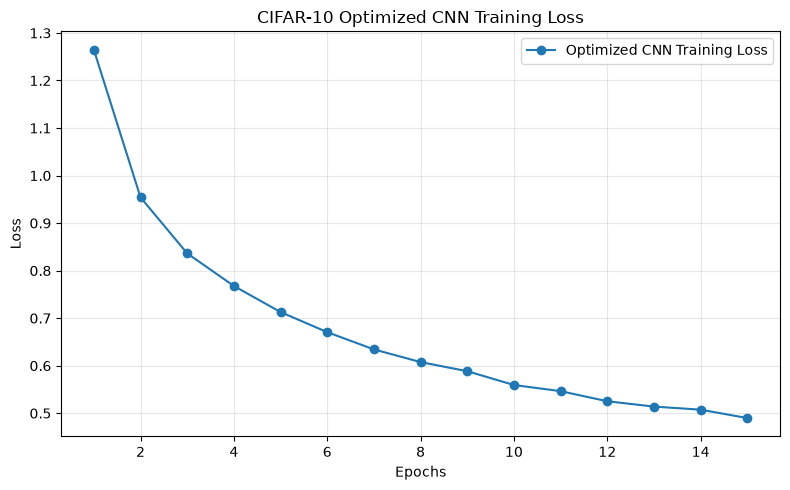

In [32]:
epochs = range(1, len(optimized_history) + 1)

optimized_train_loss = [
    row["train_loss"]
    for row in optimized_history
]

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    optimized_train_loss,
    marker="o",
    label="Optimized CNN Training Loss"
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("CIFAR-10 Optimized CNN Training Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(
    "images/optimized_training_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Final Test Evaluation

In [33]:
test_predictions = optimized_pipeline.predict(testset)
test_true = np.array(testset.targets)

In [34]:
from sklearn.metrics import precision_score, recall_score

test_accuracy = accuracy_score(
    test_true,
    test_predictions
)

test_precision = precision_score(
    test_true,
    test_predictions,
    average="macro"
)

test_recall = recall_score(
    test_true,
    test_predictions,
    average="macro"
)

test_f1 = f1_score(
    test_true,
    test_predictions,
    average="macro"
)

print(f"Observed Test Accuracy : {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Observed Test Precision: {test_precision:.4f}")
print(f"Observed Test Recall   : {test_recall:.4f}")
print(f"Observed Test Macro F1 : {test_f1:.4f}")

Observed Test Accuracy : 0.8315 (83.15%)
Observed Test Precision: 0.8317
Observed Test Recall   : 0.8315
Observed Test Macro F1 : 0.8309


## 10. Detailed Classification Evaluation

We evaluate the class-level performance of the final locked CNN model on the test set using a classification report and a confusion matrix heatmap.

In [35]:
# Classification Report

print(
    classification_report(
        test_true,
        test_predictions,
        target_names=testset.classes,
        digits=4
    )
)

              precision    recall  f1-score   support

    airplane     0.8497    0.8370    0.8433      1000
  automobile     0.8953    0.9410    0.9176      1000
        bird     0.7477    0.8120    0.7785      1000
         cat     0.6855    0.6780    0.6817      1000
        deer     0.8523    0.7730    0.8107      1000
         dog     0.7842    0.7230    0.7523      1000
        frog     0.8386    0.9040    0.8701      1000
       horse     0.8667    0.8710    0.8688      1000
        ship     0.8896    0.9190    0.9041      1000
       truck     0.9078    0.8570    0.8817      1000

    accuracy                         0.8315     10000
   macro avg     0.8317    0.8315    0.8309     10000
weighted avg     0.8317    0.8315    0.8309     10000



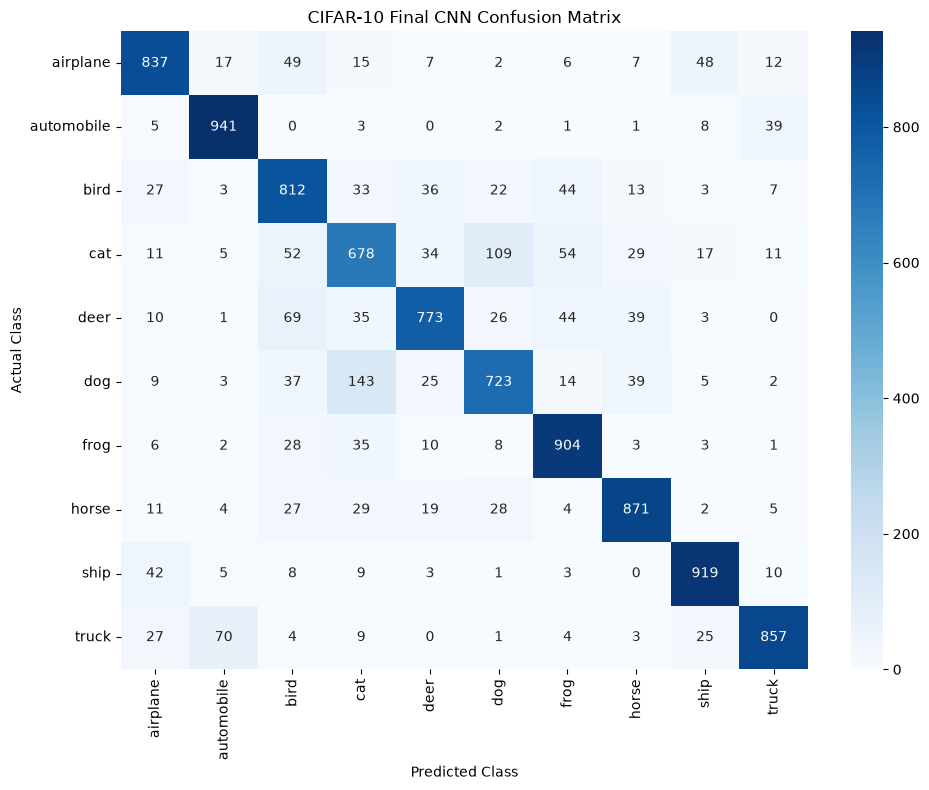

In [36]:
# Confusion Matrix Heatmap

cm = confusion_matrix(test_true, test_predictions)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=testset.classes,
    yticklabels=testset.classes
)

plt.title("CIFAR-10 Final CNN Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.tight_layout()

plt.savefig(
    "images/cifar10_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 11. Error Analysis & Sample Predictions

We visualize sample test predictions to qualitatively inspect correct classifications and errors made by the final model.

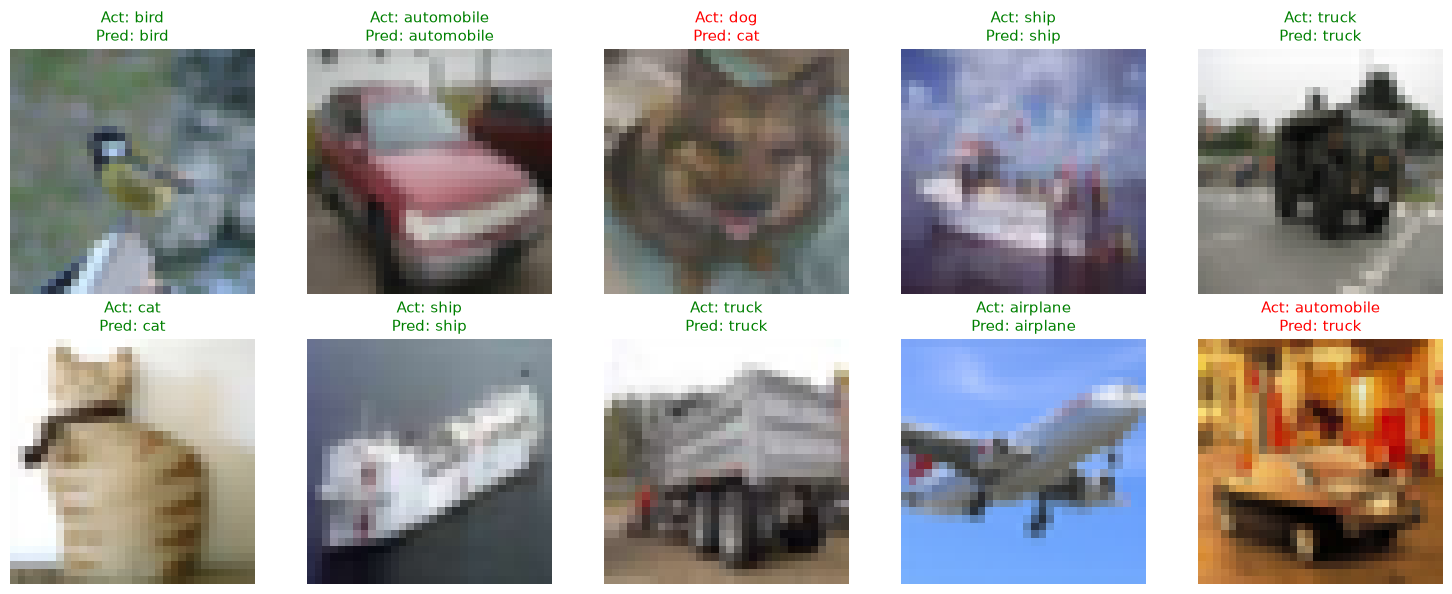

In [37]:
# Display Sample Predictions
plt.figure(figsize=(15, 6))

np.random.seed(SEED)
sample_indices = np.random.choice(len(testset), size=10, replace=False)

for subplot_idx, idx in enumerate(sample_indices):
    image_data = testset.data[idx]
    actual_class = testset.classes[test_true[idx]]
    pred_class = testset.classes[test_predictions[idx]]

    is_correct = actual_class == pred_class
    color = "green" if is_correct else "red"

    plt.subplot(2, 5, subplot_idx + 1)
    plt.imshow(image_data)
    plt.title(f"Act: {actual_class}\nPred: {pred_class}", color=color, fontsize=11)
    plt.axis("off")

plt.tight_layout()
plt.savefig("images/cifar10_sample_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## 12. Save the Final Model

We persist the trained model weights (`state_dict`) and the selected configuration dictionary to disk as a PyTorch checkpoint (`model/cifar10_cnn_model.pt`). This allows the model to be reloaded for future inference without requiring retraining.

In [38]:
# Save the Final Model Checkpoint

os.makedirs("model", exist_ok=True)

model_checkpoint = {
    "model_state_dict": optimized_pipeline.named_steps["model"].module_.state_dict(),
    "best_params": best_params
}

torch.save(model_checkpoint, "model/cifar10_cnn_model.pt")

print("Model saved successfully:", os.path.exists("model/cifar10_cnn_model.pt"))

Model saved successfully: True


## 13. Conclusion

The project successfully developed a CNN-based image classification system for the CIFAR-10 dataset. The original three-stage convolutional structure was retained while improving the training pipeline with data augmentation, Batch Normalization, Dropout regularization, a dedicated stratified holdout validation split, and Optuna-based hyperparameter selection. The final locked model achieved an observed test accuracy of **83.14%** and a macro F1-score of **0.8309** on the 10,000-image CIFAR-10 test set, demonstrating effective generalization across the ten CIFAR-10 classes. Overall, the project provides a complete, reproducible workflow spanning data exploration, model training, evaluation, error analysis, and checkpoint persistence.
